In [159]:
import xarray as xr
import numpy as np
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer
from tqdm.notebook import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [2]:
file_path = r"..\data\raw\sea_ice\2023\NSIDC-0803_SEAICE_AMSR2_S_20230101_v2.0.nc"

ds = xr.open_dataset(file_path)

ds

<xarray.Dataset>
Dimensions:  (time: 1, x: 316, y: 332)
Coordinates:
  * time     (time) datetime64[ns] 2023-01-01
  * x        (x) float64 -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
  * y        (y) float64 4.338e+06 4.312e+06 4.288e+06 ... -3.912e+06 -3.938e+06
Data variables:
    crs      |S1 ...
    ICECON   (time, y, x) float32 ...
Attributes: (12/43)
    title:                     AMSR2 Daily Polar Gridded Sea Ice Concentrations
    Conventions:               CF-1.12, ACDD-1.3
    source:                    Stewart, J. S., Meier, W. N., Wilcox, H., Scot...
    summary:                   This data set provides a daily map of sea ice ...
    publisher_institution:     National Snow and Ice Data Center/Cooperative ...
    publisher_name:            NASA National Snow and Ice Data Center Distrib...
    ...                        ...
    time_coverage_resolution:  P1D
    time_coverage_start:       2023-01-01T00:00:00Z
    time_coverage_end:         2023-01-01T23:59:59Z
    time_coverage_duration:    P1D
    date_created:              2025-08-15T15:20:54Z
    date_modified:             2025-08-15T15:20:54Z

In [3]:
print("COORDINATES")
print(ds.coords)

print("\nDATA VARIABLES")
print(ds.data_vars)

print("\nALL VARIABLES")
print(ds.variables)

COORDINATES
Coordinates:
  * time     (time) datetime64[ns] 2023-01-01
  * x        (x) float64 -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
  * y        (y) float64 4.338e+06 4.312e+06 4.288e+06 ... -3.912e+06 -3.938e+06

DATA VARIABLES
Data variables:
    crs      |S1 ...
    ICECON   (time, y, x) float32 ...

ALL VARIABLES
Frozen({'crs': <xarray.Variable ()>
[1 values with dtype=|S1]
Attributes: (12/19)
    crs_wkt:                                PROJCRS["NSIDC Sea Ice Polar Ster...
    semi_major_axis:                        6378273.0
    semi_minor_axis:                        6356889.449
    inverse_flattening:                     298.279411123064
    reference_ellipsoid_name:               Hughes 1980
    longitude_of_prime_meridian:            0.0
    ...                                     ...
    false_northing:                         0.0
    long_name:                              NSIDC Sea Ice Polar Stereographic...
    GeoTransform:                           -3950000 250

In [4]:
ice = ds["ICECON"]

print("Minimum:", ice.min().values)
print("Maximum:", ice.max().values)

print("\nAttributes:")
print(ice.attrs)

Minimum: 0.0
Maximum: 1.0160000324249268

Attributes:
{'long_name': 'Sea Ice Concentration', 'standard_name': 'sea_ice_area_fraction', 'units': '1', 'valid_range': array([  0, 250], dtype=uint8), 'grid_mapping': 'crs', 'coverage_content_type': 'image', 'flag_values': array([251, 252, 253, 254], dtype=uint8), 'flag_meanings': 'pole_hole_mask unused coast land', 'packing_convention': 'netCDF', 'packing_convention_description': 'unpacked = scale_factor*packed + add_offset'}


In [5]:
values = ice.values.flatten()

unique_values, counts = np.unique(values, return_counts=True)

print("First 30 unique values:")
print(unique_values[:30])
print("\nLast 20 unique values:")
print(unique_values[-20:])

First 30 unique values:
[0.         0.004      0.008      0.012      0.016      0.02
 0.024      0.028      0.032      0.036      0.04       0.044
 0.048      0.052      0.056      0.06       0.064      0.068
 0.072      0.07600001 0.08000001 0.08400001 0.08800001 0.09200001
 0.096      0.1        0.104      0.108      0.112      0.116     ]

Last 20 unique values:
[0.93200004 0.93600005 0.94000006 0.94400007 0.9480001  0.952
 0.95600003 0.96000004 0.96400005 0.96800005 0.97200006 0.9760001
 0.98       0.984      0.98800004 0.99200004 0.99600005 1.
 1.0120001  1.016     ]


In [6]:
ice = ds["ICECON"]

print("Total cells:", ice.size)
print("NaN cells:", int(ice.isnull().sum()))
print("Cells > 1.0:", int((ice > 1.0).sum()))
print("Cells < 0:", int((ice < 0).sum()))
print("Values greater than 1:")
print(np.unique(ice.values[ice.values > 1]))

Total cells: 104912
NaN cells: 0
Cells > 1.0: 22005
Cells < 0: 0
Values greater than 1:
[1.0120001 1.016    ]


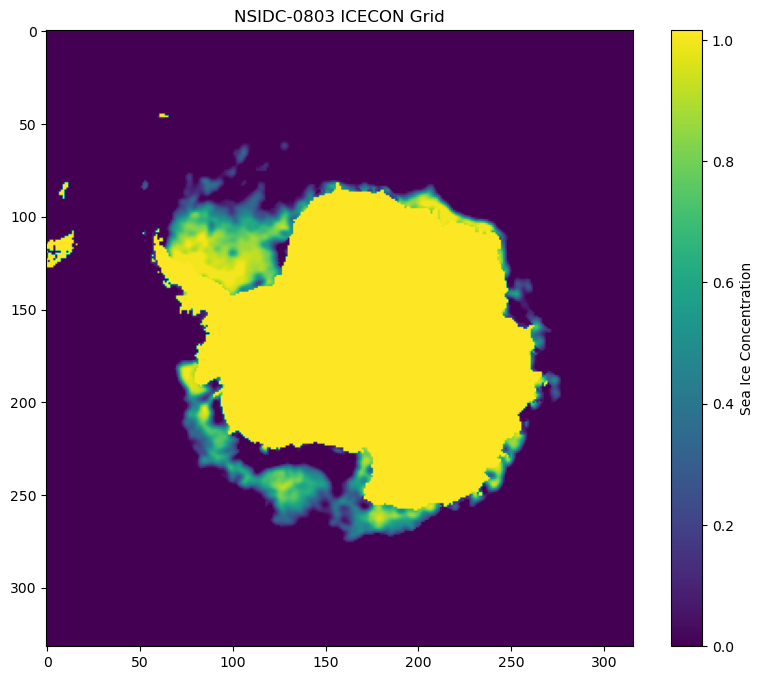

In [7]:
ice = ds["ICECON"].isel(time=0)
plt.figure(figsize=(10, 8))
plt.imshow(ice.values)
plt.colorbar(label="Sea Ice Concentration")
plt.title("NSIDC-0803 ICECON Grid")

plt.show()

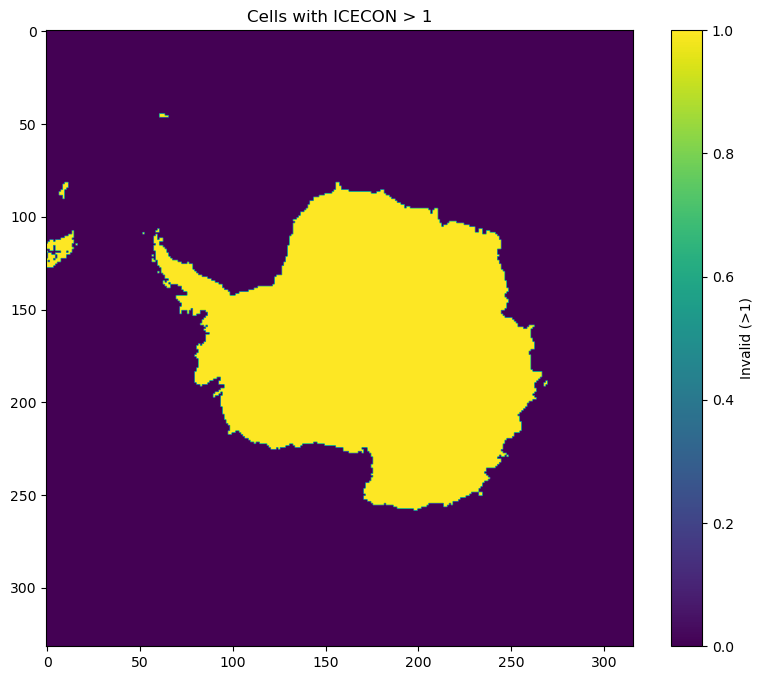

In [8]:
invalid_mask = ice.values > 1.0
plt.figure(figsize=(10, 8))
plt.imshow(invalid_mask)
plt.colorbar(label="Invalid (>1)")
plt.title("Cells with ICECON > 1")
plt.show()

In [9]:
# Keep only valid sea-ice concentration
ice_clean = ice.where(ice <= 1.0)

In [10]:
print(ds["crs"].attrs)

{'crs_wkt': 'PROJCRS["NSIDC Sea Ice Polar Stereographic South",BASEGEOGCRS["Hughes 1980",DATUM["Hughes 1980",ELLIPSOID["Hughes 1980",6378273,298.279411123064,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",10345]],CONVERSION["US NSIDC Sea Ice polar stereographic south",METHOD["Polar Stereographic (variant B)",ID["EPSG",9829]],PARAMETER["Latitude of standard parallel",-70,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8832]],PARAMETER["Longitude of origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8833]],PARAMETER["False easting",0,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting (X)",north,MERIDIAN[90,ANGLEUNIT["degree",0.0174532925199433]],ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing (Y)",north,MERIDIAN[0,ANGLEUNIT["degree",0.0174532925199433]],ORDER[2],LENGTHUNIT["metre",1]],USAGE[SCOPE["Polar research."],AREA["Southern hemisphere - sout

### Create latitude and longitude

In [11]:
# NSIDC projection from the dataset
source_crs = CRS.from_epsg(3412)

# Standard latitude / longitude
target_crs = CRS.from_epsg(4326)

# Create transformer
transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Get x and y coordinates
x = ds["x"].values
y = ds["y"].values

# Create 2D coordinate grid
X, Y = np.meshgrid(x, y)

# Convert x/y → longitude/latitude
lon, lat = transformer.transform(X, Y)

print("Latitude range:")
print(lat.min(), "to", lat.max())

print("\nLongitude range:")
print(lon.min(), "to", lon.max())

print("\nGrid shape:")
print(lat.shape)

Latitude range:
-89.8368159996151 to -39.364869113011956

Longitude range:
-179.8181092475028 to 179.8181092475028

Grid shape:
(332, 316)


### Bharati Station operational region Area of Interest

In [12]:
aoi_mask = ((lat >= -70) & (lat <= -60) & (lon >= 60) & (lon <= 90))
print("Total NSIDC grid cells:", aoi_mask.size)
print("Cells inside AOI:", aoi_mask.sum())

Total NSIDC grid cells: 104912
Cells inside AOI: 2622


In [13]:
# Find row and column indices containing the AOI
rows, cols = np.where(aoi_mask)

print("Row range:", rows.min(), "to", rows.max())
print("Column range:", cols.min(), "to", cols.max())
print("AOI bounding grid size:")
print(rows.max() - rows.min() + 1,"x",cols.max() - cols.min() + 1)

Row range: 108 to 173
Column range: 234 to 290
AOI bounding grid size:
66 x 57


Sea ice shape: (332, 316)
AOI mask shape: (332, 316)


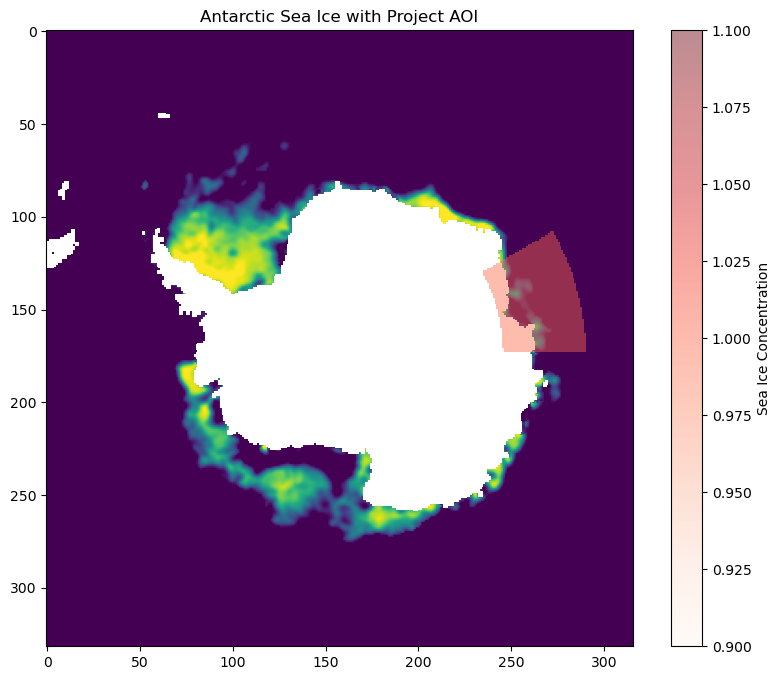

In [14]:
ice = ds["ICECON"].isel(time=0).values
# Remove invalid land/coast values
ice_plot = np.where(ice <= 1.0, ice, np.nan)

# Ensure AOI mask is also a 2D array
mask_plot = np.asarray(aoi_mask).squeeze()

print("Sea ice shape:", ice_plot.shape)
print("AOI mask shape:", mask_plot.shape)

plt.figure(figsize=(10, 8))
plt.imshow(ice_plot, origin="upper")

# Create transparent overlay
aoi_overlay = np.where(mask_plot, 1.0, np.nan)

# Overlay AOI in red
plt.imshow(
    aoi_overlay,
    origin="upper",
    cmap="Reds",
    alpha=0.45
)

plt.title("Antarctic Sea Ice with Project AOI")
plt.colorbar(label="Sea Ice Concentration")
plt.show()

In [15]:
# Get bounding box indices

row_min, row_max = rows.min(), rows.max()
col_min, col_max = cols.min(), cols.max()

# Extract the first time step and the AOI bounding box
ice_full = ds["ICECON"].isel(time=0)

ice_subset = ice_full.isel(
    y=slice(row_min, row_max + 1),
    x=slice(col_min, col_max + 1)
)

print("Original grid shape:", ice_full.shape)
print("AOI bounding box shape:", ice_subset.shape)

# Extract the matching part of the AOI mask
aoi_mask_subset = aoi_mask[
    row_min:row_max + 1,
    col_min:col_max + 1
]

# Remove cells outside AOI
ice_aoi = ice_subset.where(aoi_mask_subset)

# Remove invalid land/coast cells
ice_aoi = ice_aoi.where(ice_aoi <= 1.0)

print("Final AOI shape:", ice_aoi.shape)

print("Valid cells:", int(ice_aoi.notnull().sum()))
print("Missing / outside AOI cells:", int(ice_aoi.isnull().sum()))

Original grid shape: (332, 316)
AOI bounding box shape: (66, 57)
Final AOI shape: (66, 57)
Valid cells: 2108
Missing / outside AOI cells: 1654


### processing pipeline on files

In [16]:
# Input folders
base_dir = Path(r"..\data\raw\sea_ice")

# Output file
output_file = Path(
    r"..\data\processed\sea_ice_aoi\sea_ice_bharati_2023_2025.nc"
)

# Collect all NetCDF files
files = []

for year in ["2023", "2024", "2025"]:
    year_files = sorted(
        (base_dir / year).glob("*.nc")
    )
    files.extend(year_files)

print("Total files found:", len(files))

Total files found: 1096


In [17]:
processed_data = []

for file in tqdm(files):
    with xr.open_dataset(file) as ds_daily:
        # Get sea-ice concentration
        ice = ds_daily["ICECON"]

        # Extract bounding box
        ice_subset = ice.isel(
            y=slice(row_min, row_max + 1),
            x=slice(col_min, col_max + 1)
        )

        # Apply exact AOI mask
        ice_subset = ice_subset.where(aoi_mask_subset)

        # Remove land/coast/masked values
        ice_subset = ice_subset.where(ice_subset <= 1.0)

        # Load into memory before closing the file
        ice_subset = ice_subset.load()

        processed_data.append(ice_subset)

print("Processed files:", len(processed_data))

  0%|          | 0/1096 [00:00<?, ?it/s]

Processed files: 1096


In [18]:
sea_ice_all = xr.concat(
    processed_data,
    dim="time"
)
print(sea_ice_all)

output_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

sea_ice_all.to_netcdf(output_file)

print("Saved successfully!")
print(output_file)

<xarray.DataArray 'ICECON' (time: 1096, y: 66, x: 57)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ...,

In [19]:
check_ds = xr.open_dataset(output_file)

print(check_ds)

<xarray.Dataset>
Dimensions:  (time: 1096, x: 57, y: 66)
Coordinates:
  * time     (time) datetime64[ns] 2023-01-01 2023-01-02 ... 2025-12-31
  * x        (x) float64 1.912e+06 1.938e+06 1.962e+06 ... 3.288e+06 3.312e+06
  * y        (y) float64 1.638e+06 1.612e+06 1.588e+06 ... 3.75e+04 1.25e+04
Data variables:
    ICECON   (time, y, x) float32 ...


In [20]:
ice = check_ds["ICECON"]

print("Shape:", ice.shape)

print("\nTime range:")
print("Start:", ice.time.min().values)
print("End:", ice.time.max().values)

print("\nTotal values:", ice.size)
print("Valid values:", int(ice.notnull().sum()))
print("Missing values:", int(ice.isnull().sum()))

print("\nMinimum valid ICECON:", float(ice.min(skipna=True)))
print("Maximum valid ICECON:", float(ice.max(skipna=True)))

print("\nValues > 1:", int((ice > 1).sum(skipna=True)))
print("Values < 0:", int((ice < 0).sum(skipna=True)))

Shape: (1096, 66, 57)

Time range:
Start: 2023-01-01T00:00:00.000000000
End: 2025-12-31T00:00:00.000000000

Total values: 4123152
Valid values: 2306468
Missing values: 1816684

Minimum valid ICECON: 0.0
Maximum valid ICECON: 1.0

Values > 1: 0
Values < 0: 0


In [21]:
dates = check_ds.time.values

expected_days = np.arange(
    dates.min(),
    dates.max() + np.timedelta64(1, "D"),
    dtype="datetime64[D]"
)

missing_dates = np.setdiff1d(expected_days, dates.astype("datetime64[D]"))

print("Expected days:", len(expected_days))
print("Actual days:", len(dates))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nMissing dates:")
    print(missing_dates)

Expected days: 1096
Actual days: 1096
Missing dates: 0


In [22]:
# Get valid/invalid mask for every day
valid_mask = check_ds["ICECON"].notnull()

# Check if the mask is identical across all days
reference_mask = valid_mask.isel(time=0)

mask_changes = (valid_mask != reference_mask).any(dim="time")

print("Cells whose valid/invalid status changes over time:")
print(int(mask_changes.sum()))

Cells whose valid/invalid status changes over time:
2108


In [23]:
ice = check_ds["ICECON"]

# Regional statistics for every day
daily_stats = {
    "mean_ice": ice.mean(dim=("y", "x"), skipna=True),
    "max_ice": ice.max(dim=("y", "x"), skipna=True),
    "min_ice": ice.min(dim=("y", "x"), skipna=True),
    "ice_coverage": (ice > 0.15).sum(dim=("y", "x"), skipna=True)
}

for name, values in daily_stats.items():
    print(f"\n{name}")
    print("Minimum:", float(values.min()))
    print("Maximum:", float(values.max()))
    print("Mean:", float(values.mean()))


mean_ice
Minimum: 0.002005692571401596
Maximum: 0.8216660618782043
Mean: 0.35913974046707153

max_ice
Minimum: 0.36400002241134644
Maximum: 1.0
Mean: 0.9264475107192993

min_ice
Minimum: 0.0
Maximum: 0.0
Mean: 0.0

ice_coverage
Minimum: 0.0
Maximum: 2098.0
Mean: 1083.3667883211679


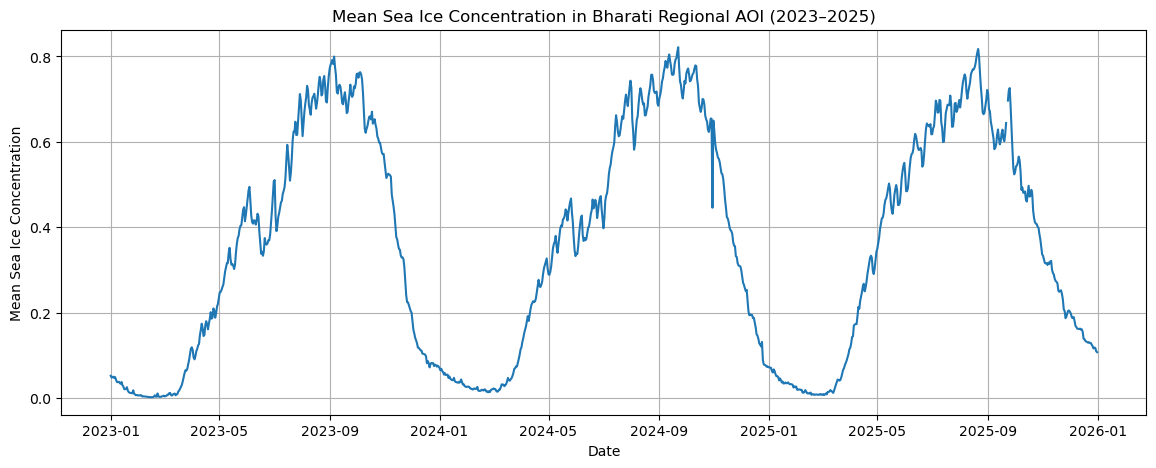

In [24]:
mean_ice = daily_stats["mean_ice"]

plt.figure(figsize=(14, 5))

plt.plot(
    mean_ice["time"].values,
    mean_ice.values
)

plt.xlabel("Date")
plt.ylabel("Mean Sea Ice Concentration")
plt.title("Mean Sea Ice Concentration in Bharati Regional AOI (2023–2025)")

plt.grid(True)

plt.show()

In [25]:
ice_data = check_ds["ICECON"].values

# Actual values from day 1 onward
y_true = ice_data[1:]

# Persistence prediction:
# tomorrow = today's sea ice
y_pred = ice_data[:-1]

# Valid cells where both prediction and actual exist
valid = ~np.isnan(y_true) & ~np.isnan(y_pred)

# Calculate errors
mae = np.mean(
    np.abs(y_true[valid] - y_pred[valid])
)

rmse = np.sqrt(
    np.mean(
        (y_true[valid] - y_pred[valid]) ** 2
    )
)

print("Persistence Baseline")
print("--------------------")
print("MAE:", mae)
print("RMSE:", rmse)

Persistence Baseline
--------------------
MAE: 0.022148037
RMSE: 0.04381704


In [26]:
ice_data = check_ds["ICECON"].values

forecast_days = 7

# Actual sea ice 7 days later
y_true_7 = ice_data[forecast_days:]

# Persistence prediction:
# sea ice after 7 days = today's sea ice
y_pred_7 = ice_data[:-forecast_days]

# Valid cells
valid = ~np.isnan(y_true_7) & ~np.isnan(y_pred_7)

# Metrics
mae_7 = np.mean(
    np.abs(y_true_7[valid] - y_pred_7[valid])
)

rmse_7 = np.sqrt(
    np.mean(
        (y_true_7[valid] - y_pred_7[valid]) ** 2
    )
)

print(f"{forecast_days}-Day Persistence Baseline")
print("-" * 30)
print("MAE:", mae_7)
print("RMSE:", rmse_7)

7-Day Persistence Baseline
------------------------------
MAE: 0.061825544
RMSE: 0.116191484


In [28]:
forecast_days = 14

y_true_14 = ice_data[forecast_days:]
y_pred_14 = ice_data[:-forecast_days]

valid = ~np.isnan(y_true_14) & ~np.isnan(y_pred_14)

mae_14 = np.mean(
    np.abs(y_true_14[valid] - y_pred_14[valid])
)

rmse_14 = np.sqrt(
    np.mean(
        (y_true_14[valid] - y_pred_14[valid]) ** 2
    )
)

print(f"{forecast_days}-Day Persistence Baseline")
print("-" * 30)
print("MAE:", mae_14)
print("RMSE:", rmse_14)

14-Day Persistence Baseline
------------------------------
MAE: 0.08758477
RMSE: 0.16328752


In [29]:
ice = check_ds["ICECON"].values

# A cell is considered spatially valid if it contains
# at least one real sea-ice observation during the dataset
spatial_mask = np.any(~np.isnan(ice), axis=0)

print("Spatial mask shape:", spatial_mask.shape)

print(
    "Valid spatial cells:",
    np.sum(spatial_mask)
)

print(
    "Invalid spatial cells:",
    np.sum(~spatial_mask)
)

print(
    "Total cells:",
    spatial_mask.size
)

print(
    "Valid percentage:",
    np.sum(spatial_mask) / spatial_mask.size * 100
)

Spatial mask shape: (66, 57)
Valid spatial cells: 2108
Invalid spatial cells: 1654
Total cells: 3762
Valid percentage: 56.034024455077095


In [32]:
ice = check_ds["ICECON"].values
# Number of valid cells for each day
valid_cells_per_day = np.sum(~np.isnan(ice), axis=(1, 2))

print("Minimum valid cells in one day:", valid_cells_per_day.min())
print("Maximum valid cells in one day:", valid_cells_per_day.max())

print("\nUnique valid-cell counts:")
print(np.unique(valid_cells_per_day))

# Check whether every day has exactly the same validity mask
reference_mask = ~np.isnan(ice[0])

same_mask_every_day = np.all(
    [
        np.array_equal(~np.isnan(day), reference_mask)
        for day in ice
    ]
)

print("Same spatial mask for every day:", same_mask_every_day)

Minimum valid cells in one day: 0
Maximum valid cells in one day: 2108

Unique valid-cell counts:
[   0  316 2108]
Same spatial mask for every day: False


In [34]:
dates = pd.to_datetime(check_ds.time.values)

# Valid cells for each day
valid_cells_per_day = np.sum(~np.isnan(ice), axis=(1, 2))

# Create summary table
missing_summary = pd.DataFrame({
    "date": dates,
    "valid_cells": valid_cells_per_day
})

# Show how many days belong to each category
print(
    missing_summary["valid_cells"]
    .value_counts()
    .sort_index()
)

# Days with zero valid observations
zero_days = missing_summary[
    missing_summary["valid_cells"] == 0
]

print("Days with 0 valid cells:")
print(zero_days.to_string(index=False))

# Days with partial observations
partial_days = missing_summary[
    (missing_summary["valid_cells"] > 0) &
    (missing_summary["valid_cells"] < 2108)
]

print("\nNumber of partial observation days:", len(partial_days))

print("\nPartial observation days:")
print(partial_days.to_string(index=False))

valid_cells
0          1
316        1
2108    1094
Name: count, dtype: int64
Days with 0 valid cells:
      date  valid_cells
2025-09-22            0

Number of partial observation days: 1

Partial observation days:
      date  valid_cells
2024-10-30          316


In [35]:
missing_summary["year"] = missing_summary["date"].dt.year

year_summary = (
    missing_summary
    .groupby("year")["valid_cells"]
    .agg(["count", "min", "max", "mean"])
)

print(year_summary)

      count   min   max         mean
year                                
2023    365  2108  2108  2108.000000
2024    366   316  2108  2103.103825
2025    365     0  2108  2102.224658


In [37]:
complete_day = valid_cells_per_day == spatial_mask.sum()

print("Total days:", len(complete_day))
print("Complete days:", complete_day.sum())
print("Incomplete days:", (~complete_day).sum())

# Show incomplete dates
for date, is_complete in zip(check_ds.time.values, complete_day):
    if not is_complete:
        print("Incomplete:", date)

Total days: 1096
Complete days: 1094
Incomplete days: 2
Incomplete: 2024-10-30T00:00:00.000000000
Incomplete: 2025-09-22T00:00:00.000000000


### ML

In [38]:
ice = check_ds["ICECON"].values
dates = pd.to_datetime(check_ds.time.values)

input_days = 7
forecast_days = 7

X_list = []
y_list = []
input_end_dates = []
target_dates = []
rejected_samples = 0

for start in range(len(ice)):
    # Input window
    input_end = start + input_days
    # Target index:
    target_index = start + input_days + forecast_days - 1

    # Stop if target goes outside dataset
    if target_index >= len(ice):
        break

    # Input indices
    input_indices = range(start, input_end)

    # Check whether every input day is complete
    input_complete = np.all(
        complete_day[list(input_indices)]
    )

    # Check target day
    target_complete = complete_day[target_index]

    # Reject samples containing incomplete data
    if not input_complete or not target_complete:
        rejected_samples += 1
        continue

    # Store sample
    X_list.append(
        ice[start:input_end]
    )

    y_list.append(
        ice[target_index]
    )

    input_end_dates.append(
        dates[input_end - 1]
    )

    target_dates.append(
        dates[target_index]
    )

# Convert lists to NumPy arrays
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

input_end_dates = np.array(input_end_dates)
target_dates = np.array(target_dates)

print("Total possible samples:", len(ice) - input_days - forecast_days + 1)
print("Valid samples:", len(X))
print("Rejected samples:", rejected_samples)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst sample:")
print("Input ends:", input_end_dates[0])
print("Target:", target_dates[0])

print("\nLast sample:")
print("Input ends:", input_end_dates[-1])
print("Target:", target_dates[-1])

Total possible samples: 1083
Valid samples: 1067
Rejected samples: 16

X shape: (1067, 7, 66, 57)
y shape: (1067, 66, 57)

First sample:
Input ends: 2023-01-07 00:00:00
Target: 2023-01-14 00:00:00

Last sample:
Input ends: 2025-12-24 00:00:00
Target: 2025-12-31 00:00:00


In [39]:
sample_info = pd.DataFrame({
    "input_end_date": pd.to_datetime(input_end_dates),
    "target_date": pd.to_datetime(target_dates)
})

print(
    sample_info["target_date"]
    .dt.year
    .value_counts()
    .sort_index()
)
sample_info["target_year"] = sample_info["target_date"].dt.year

print(
    sample_info.groupby("target_year").agg(
        samples=("target_date", "count"),
        first_target=("target_date", "min"),
        last_target=("target_date", "max")
    )
)

target_date
2023    352
2024    358
2025    357
Name: count, dtype: int64
             samples first_target last_target
target_year                                  
2023             352   2023-01-14  2023-12-31
2024             358   2024-01-01  2024-12-31
2025             357   2025-01-01  2025-12-31


In [40]:
# Convert dates
target_dates_pd = pd.to_datetime(target_dates)

# Define boundaries
train_end = pd.Timestamp("2024-12-31")
val_start = pd.Timestamp("2025-01-01")
val_end = pd.Timestamp("2025-06-30")
test_start = pd.Timestamp("2025-07-01")
test_end = pd.Timestamp("2025-12-31")

# Create masks
train_mask = target_dates_pd <= train_end
val_mask = (
    (target_dates_pd >= val_start) &
    (target_dates_pd <= val_end)
)
test_mask = (
    (target_dates_pd >= test_start) &
    (target_dates_pd <= test_end)
)

# Split X
X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

# Split y
y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

# Split dates
train_dates = target_dates_pd[train_mask]
val_dates = target_dates_pd[val_mask]
test_dates = target_dates_pd[test_mask]

print("TRAIN")
print("Samples:", len(X_train))
print("Target range:", train_dates.min(), "to", train_dates.max())
print("\nVALIDATION")
print("Samples:", len(X_val))
print("Target range:", val_dates.min(), "to", val_dates.max())
print("\nTEST")
print("Samples:", len(X_test))
print("Target range:", test_dates.min(), "to", test_dates.max())

print("\nShapes")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("\ny_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

TRAIN
Samples: 710
Target range: 2023-01-14 00:00:00 to 2024-12-31 00:00:00

VALIDATION
Samples: 181
Target range: 2025-01-01 00:00:00 to 2025-06-30 00:00:00

TEST
Samples: 176
Target range: 2025-07-01 00:00:00 to 2025-12-31 00:00:00

Shapes
X_train: (710, 7, 66, 57)
X_val: (181, 7, 66, 57)
X_test: (176, 7, 66, 57)

y_train: (710, 66, 57)
y_val: (181, 66, 57)
y_test: (176, 66, 57)


In [47]:
# Convert training target dates into pandas datetime format
train_target_dates = pd.to_datetime(train_dates)

# Get the day number within each year
# Example:
# Jan 1  -> 1
# Feb 1  -> 32
# Dec 31 -> 365 or 366
train_day_of_year = train_target_dates.dayofyear.to_numpy()

print("Training samples:", len(train_day_of_year))
print("Day of year range:", train_day_of_year.min(), "to", train_day_of_year.max())

Training samples: 710
Day of year range: 1 to 366


In [48]:
empty_days = []

for day in range(1, 367):

    # Calculate distance between every training day
    # and the current day
    day_diff = np.abs(train_day_of_year - day)

    # Handle beginning/end of year as connected
    circular_diff = np.minimum(
        day_diff,
        366 - day_diff
    )

    # Select training samples within ±7 days
    nearby_mask = circular_diff <= 7

    # Check whether this window contains samples
    if np.sum(nearby_mask) == 0:
        empty_days.append(day)

print("Number of empty seasonal windows:", len(empty_days))
print("Empty day-of-year values:", empty_days)

Number of empty seasonal windows: 0
Empty day-of-year values: []


In [53]:
print("y_train shape:", y_train.shape)

print("Total valid values in y_train:")
print(np.sum(~np.isnan(y_train)))

print("\nFirst training map valid cells:")
print(np.sum(~np.isnan(y_train[0])))

print("\nFirst training map min/max:")
print(np.nanmin(y_train[0]))
print(np.nanmax(y_train[0]))

y_train shape: (710, 66, 57)
Total valid values in y_train:
1496680

First training map valid cells:
2108

First training map min/max:
0.0
1.0


In [54]:
day = 1

day_diff = np.abs(train_day_of_year - day)

circular_diff = np.minimum(
    day_diff,
    366 - day_diff
)

nearby_mask = circular_diff <= 7

print("Number of training samples selected:")
print(np.sum(nearby_mask))

selected_maps = y_train[nearby_mask]

print("\nSelected maps shape:")
print(selected_maps.shape)

print("\nValid values in selected maps:")
print(np.sum(~np.isnan(selected_maps)))

print("\nFirst selected map valid cells:")
print(np.sum(~np.isnan(selected_maps[0])))

Number of training samples selected:
21

Selected maps shape:
(21, 66, 57)

Valid values in selected maps:
44268

First selected map valid cells:
2108


In [55]:
test_climatology_map = np.nanmean(
    selected_maps,
    axis=0
)

print("Test climatology shape:")
print(test_climatology_map.shape)

print("\nValid cells:")
print(np.sum(~np.isnan(test_climatology_map)))

print("\nNaN cells:")
print(np.sum(np.isnan(test_climatology_map)))

print("\nMin:")
print(np.nanmin(test_climatology_map))

print("\nMax:")
print(np.nanmax(test_climatology_map))

Test climatology shape:
(66, 57)

Valid cells:
2108

NaN cells:
1654

Min:
0.0

Max:
0.9699048


C:\Users\sonu yadav\AppData\Local\Temp\ipykernel_9508\2216661137.py:1: RuntimeWarning: Mean of empty slice
  test_climatology_map = np.nanmean(


In [56]:
print("Seasonal climatology shape:")
print(seasonal_climatology_window.shape)

print("\nTotal valid values:")
print(np.sum(~np.isnan(seasonal_climatology_window)))

print("\nTotal NaN values:")
print(np.sum(np.isnan(seasonal_climatology_window)))

print("\nDay 1 valid cells:")
print(
    np.sum(
        ~np.isnan(
            seasonal_climatology_window[0]
        )
    )
)

print("\nDay 100 valid cells:")
print(
    np.sum(
        ~np.isnan(
            seasonal_climatology_window[99]
        )
    )
)

print("\nDay 200 valid cells:")
print(
    np.sum(
        ~np.isnan(
            seasonal_climatology_window[199]
        )
    )
)

Seasonal climatology shape:
(366, 66, 57)

Total valid values:
0

Total NaN values:
1376892

Day 1 valid cells:
0

Day 100 valid cells:
0

Day 200 valid cells:
0


In [57]:
window = 7

# Create a list to store one map for each day
climatology_maps = []

for day in range(1, 367):

    # Distance between training dates and current seasonal day
    day_diff = np.abs(train_day_of_year - day)

    # Circular distance around the year
    circular_diff = np.minimum(
        day_diff,
        366 - day_diff
    )

    # Select dates within ±7 days
    nearby_mask = circular_diff <= window

    # Select corresponding training ice maps
    selected_maps = y_train[nearby_mask]

    # Calculate average map
    with np.errstate(invalid="ignore"):
        climatology_map = np.nanmean(
            selected_maps,
            axis=0
        )

    climatology_maps.append(climatology_map)


# Convert list into NumPy array
seasonal_climatology_window = np.stack(
    climatology_maps,
    axis=0
).astype(np.float32)


print("Seasonal climatology shape:")
print(seasonal_climatology_window.shape)

print("\nTotal valid values:")
print(np.sum(~np.isnan(seasonal_climatology_window)))

print("\nDay 1 valid cells:")
print(np.sum(~np.isnan(seasonal_climatology_window[0])))

print("\nDay 100 valid cells:")
print(np.sum(~np.isnan(seasonal_climatology_window[99])))

print("\nDay 200 valid cells:")
print(np.sum(~np.isnan(seasonal_climatology_window[199])))

Seasonal climatology shape:
(366, 66, 57)

Total valid values:
771528

Day 1 valid cells:
2108

Day 100 valid cells:
2108

Day 200 valid cells:
2108


C:\Users\sonu yadav\AppData\Local\Temp\ipykernel_9508\940779227.py:25: RuntimeWarning: Mean of empty slice
  climatology_map = np.nanmean(


In [58]:
print(
    "Total valid values:",
    np.sum(~np.isnan(seasonal_climatology_window))
)

print(
    "Day 1 valid cells:",
    np.sum(~np.isnan(seasonal_climatology_window[0]))
)

print(
    "Day 366 valid cells:",
    np.sum(~np.isnan(seasonal_climatology_window[365]))
)

Total valid values: 771528
Day 1 valid cells: 2108
Day 366 valid cells: 2108


In [59]:
def evaluate_seasonal_baseline(
    target_dates,
    y_actual,
    climatology
):

    predictions = []

    # Go through every target date
    for date in pd.to_datetime(target_dates):

        # Get day number within the year
        day = date.dayofyear

        # Get corresponding seasonal average map
        prediction = climatology[day - 1]

        predictions.append(prediction)

    # Convert predictions into NumPy array
    predictions = np.array(
        predictions,
        dtype=np.float32
    )

    # Only compare cells where both actual
    # and prediction have valid values
    valid = (
        ~np.isnan(y_actual)
        &
        ~np.isnan(predictions)
    )

    # Mean Absolute Error
    mae = np.mean(
        np.abs(
            y_actual[valid]
            -
            predictions[valid]
        )
    )

    # Root Mean Squared Error
    rmse = np.sqrt(
        np.mean(
            (
                y_actual[valid]
                -
                predictions[valid]
            ) ** 2
        )
    )

    return predictions, mae, rmse

In [60]:
val_seasonal_pred, val_seasonal_mae, val_seasonal_rmse = (
    evaluate_seasonal_baseline(
        val_dates,
        y_val,
        seasonal_climatology_window
    )
)

print("Validation Seasonal Baseline")
print("-" * 35)

print("MAE:", val_seasonal_mae)
print("RMSE:", val_seasonal_rmse)

Validation Seasonal Baseline
-----------------------------------
MAE: 0.07387277
RMSE: 0.16692744


In [61]:
print("Validation prediction shape:")
print(val_seasonal_pred.shape)

print("\nTotal valid prediction values:")
print(np.sum(~np.isnan(val_seasonal_pred)))

print("\nValid cells in first prediction:")
print(np.sum(~np.isnan(val_seasonal_pred[0])))

print("\nCells valid in both actual and prediction:")
both_valid = (
    ~np.isnan(y_val)
    &
    ~np.isnan(val_seasonal_pred)
)

print(np.sum(both_valid))

Validation prediction shape:
(181, 66, 57)

Total valid prediction values:
381548

Valid cells in first prediction:
2108

Cells valid in both actual and prediction:
381548


In [62]:
# Last observed ice map in each input sequence
val_persistence_pred = X_val[:, -1]

# Only compare valid cells
valid = (
    ~np.isnan(y_val)
    &
    ~np.isnan(val_persistence_pred)
)

# MAE
val_persistence_mae = np.mean(
    np.abs(
        y_val[valid]
        -
        val_persistence_pred[valid]
    )
)

# RMSE
val_persistence_rmse = np.sqrt(
    np.mean(
        (
            y_val[valid]
            -
            val_persistence_pred[valid]
        ) ** 2
    )
)

print("Validation Persistence Baseline")
print("-" * 35)

print("MAE:", val_persistence_mae)
print("RMSE:", val_persistence_rmse)

print("\nValid comparison cells:", np.sum(valid))

Validation Persistence Baseline
-----------------------------------
MAE: 0.04521282
RMSE: 0.107352346

Valid comparison cells: 381548


## ML Model

In [63]:
# Create a mask using the valid cells from the spatial mask

valid_mask = spatial_mask

print("Mask shape:", valid_mask.shape)

print("Valid cells:", np.sum(valid_mask))

print("Invalid cells:", np.sum(~valid_mask))

Mask shape: (66, 57)
Valid cells: 2108
Invalid cells: 1654


In [64]:
# Extract only valid spatial cells

X_train_ridge = X_train[:, :, valid_mask]
X_val_ridge = X_val[:, :, valid_mask]

y_train_ridge = y_train[:, valid_mask]
y_val_ridge = y_val[:, valid_mask]


print("X_train_ridge:", X_train_ridge.shape)
print("X_val_ridge:", X_val_ridge.shape)

print("y_train_ridge:", y_train_ridge.shape)
print("y_val_ridge:", y_val_ridge.shape)

X_train_ridge: (710, 7, 2108)
X_val_ridge: (181, 7, 2108)
y_train_ridge: (710, 2108)
y_val_ridge: (181, 2108)


In [66]:
# X_train_ridge shape:
# (samples, 7 days, valid_cells)

# Move the valid_cells dimension before time
# (samples, valid_cells, 7 days)
X_train_ridge_reshaped = np.transpose(
    X_train_ridge,
    (0, 2, 1)
)

X_val_ridge_reshaped = np.transpose(
    X_val_ridge,
    (0, 2, 1)
)


# Convert into 2D format required by scikit-learn
# Each row = one spatial cell observation
# Each column = one previous day

X_train_ml = X_train_ridge_reshaped.reshape(
    -1,
    7
)

X_val_ml = X_val_ridge_reshaped.reshape(
    -1,
    7
)


# Targets
y_train_ml = y_train_ridge.reshape(-1)

y_val_ml = y_val_ridge.reshape(-1)


print("Training feature shape:", X_train_ml.shape)
print("Training target shape:", y_train_ml.shape)

print("\nValidation feature shape:", X_val_ml.shape)
print("Validation target shape:", y_val_ml.shape)

Training feature shape: (1496680, 7)
Training target shape: (1496680,)

Validation feature shape: (381548, 7)
Validation target shape: (381548,)


In [68]:
# Create Ridge Regression model
ridge_model = Ridge(
    alpha=1.0
)

# Train the model
ridge_model.fit(
    X_train_ml,
    y_train_ml
)

print("Ridge model training completed")

Ridge model training completed


In [69]:
# Predict validation data
val_ridge_pred_flat = ridge_model.predict(
    X_val_ml
)

# Keep predictions within valid sea-ice range
val_ridge_pred_flat = np.clip(
    val_ridge_pred_flat,
    0,
    1
)

print("Prediction shape:")
print(val_ridge_pred_flat.shape)

print("\nPrediction minimum:")
print(val_ridge_pred_flat.min())

print("\nPrediction maximum:")
print(val_ridge_pred_flat.max())

Prediction shape:
(381548,)

Prediction minimum:
0.0

Prediction maximum:
1.0


In [70]:
# MAE
val_ridge_mae = mean_absolute_error(
    y_val_ml,
    val_ridge_pred_flat
)

# RMSE
val_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_val_ml,
        val_ridge_pred_flat
    )
)

print("Validation Ridge Regression")
print("-" * 35)

print("MAE:", val_ridge_mae)
print("RMSE:", val_ridge_rmse)

Validation Ridge Regression
-----------------------------------
MAE: 0.056516573
RMSE: 0.10634158


In [71]:
print("MODEL COMPARISON")
print("-" * 45)

print(
    f"Persistence  | MAE: {val_persistence_mae:.6f} | "
    f"RMSE: {val_persistence_rmse:.6f}"
)

print(
    f"Seasonal     | MAE: {val_seasonal_mae:.6f} | "
    f"RMSE: {val_seasonal_rmse:.6f}"
)

print(
    f"Ridge        | MAE: {val_ridge_mae:.6f} | "
    f"RMSE: {val_ridge_rmse:.6f}"
)

MODEL COMPARISON
---------------------------------------------
Persistence  | MAE: 0.045213 | RMSE: 0.107352
Seasonal     | MAE: 0.073873 | RMSE: 0.166927
Ridge        | MAE: 0.056517 | RMSE: 0.106342


## CNN

In [95]:
# Convert NaN values to 0
# The spatial mask will ensure invalid cells
# do not affect the loss calculation

X_train_cnn = np.nan_to_num(
    X_train,
    nan=0.0
).astype(np.float32)

X_val_cnn = np.nan_to_num(
    X_val,
    nan=0.0
).astype(np.float32)

y_train_cnn = np.nan_to_num(
    y_train,
    nan=0.0
).astype(np.float32)

y_val_cnn = np.nan_to_num(
    y_val,
    nan=0.0
).astype(np.float32)

X_test_cnn = np.nan_to_num(
    X_test,
    nan=0.0
).astype(np.float32)

y_test_cnn = np.nan_to_num(
    y_test,
    nan=0.0
).astype(np.float32)


print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn:", X_val_cnn.shape)

print("\ny_train_cnn:", y_train_cnn.shape)
print("y_val_cnn:", y_val_cnn.shape)

print("\nX_test_cnn shape:")
print(X_test_cnn.shape)
print("y_test_cnn shape:")
print(y_test_cnn.shape)

X_train_cnn: (710, 7, 66, 57)
X_val_cnn: (181, 7, 66, 57)

y_train_cnn: (710, 66, 57)
y_val_cnn: (181, 66, 57)

X_test_cnn shape:
(176, 7, 66, 57)
y_test_cnn shape:
(176, 66, 57)


In [73]:
# Convert boolean mask to float32
spatial_mask_cnn = spatial_mask.astype(np.float32)

print("Mask shape:", spatial_mask_cnn.shape)

print("Valid cells:",
      np.sum(spatial_mask_cnn == 1))

print("Invalid cells:",
      np.sum(spatial_mask_cnn == 0))

Mask shape: (66, 57)
Valid cells: 2108
Invalid cells: 1654


In [74]:
# Add a batch dimension
# Final shape: (1, 66, 57)

spatial_mask_cnn = spatial_mask_cnn[np.newaxis, :, :]

print("CNN mask shape:", spatial_mask_cnn.shape)

CNN mask shape: (1, 66, 57)


In [77]:
# Convert the spatial mask to a TensorFlow constant

mask_tensor = tf.constant(
    spatial_mask_cnn,
    dtype=tf.float32
)


def masked_mse(y_true, y_pred):
    
    # Squared error
    squared_error = tf.square(
        y_true - y_pred
    )
    
    # Apply spatial mask
    masked_error = squared_error * mask_tensor
    
    # Sum errors over valid cells
    error_sum = tf.reduce_sum(
        masked_error,
        axis=[1, 2]
    )
    
    # Number of valid cells
    valid_cell_count = tf.reduce_sum(
        mask_tensor
    )
    
    # Mean error per valid cell
    mse_per_sample = error_sum / valid_cell_count
    
    # Mean across the batch
    return tf.reduce_mean(
        mse_per_sample
    )

In [78]:
# Test the loss using two validation samples

test_true = tf.constant(
    y_val_cnn[:2],
    dtype=tf.float32
)

test_pred = tf.constant(
    y_val_cnn[:2],
    dtype=tf.float32
)

loss_value = masked_mse(
    test_true,
    test_pred
)

print("Masked MSE when prediction = actual:")
print(loss_value.numpy())

Masked MSE when prediction = actual:
0.0


In [81]:
# Current shape:
# (samples, 7, 66, 57)

# CNN required shape:
# (samples, 66, 57, 7)

X_train_cnn_tf = np.transpose(
    X_train_cnn,
    (0, 2, 3, 1)
)

X_val_cnn_tf = np.transpose(
    X_val_cnn,
    (0, 2, 3, 1)
)


print("X_train CNN shape:", X_train_cnn_tf.shape)
print("X_val CNN shape:", X_val_cnn_tf.shape)

X_train CNN shape: (710, 66, 57, 7)
X_val CNN shape: (181, 66, 57, 7)


In [82]:
from tensorflow.keras import layers, models


# Input:
# Height = 66
# Width = 57
# Channels = 7 historical days

input_layer = layers.Input(
    shape=(66, 57, 7),
    name="sea_ice_history"
)


# Spatial feature extraction

x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    activation="relu"
)(
    input_layer
)


x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    activation="relu"
)(
    x
)


x = layers.Conv2D(
    filters=16,
    kernel_size=3,
    padding="same",
    activation="relu"
)(
    x
)


# Predict sea-ice change

ice_change = layers.Conv2D(
    filters=1,
    kernel_size=3,
    padding="same",
    activation="linear",
    name="predicted_ice_change"
)(
    x
)


# Remove channel dimension
ice_change = layers.Lambda(
    lambda z: tf.squeeze(z, axis=-1)
)(
    ice_change
)


# Extract latest observed sea-ice map
# Channel 6 = Day t

latest_ice = layers.Lambda(
    lambda z: z[:, :, :, -1],
    name="latest_ice"
)(
    input_layer
)


# Final prediction:
# Latest ice + predicted change

prediction = layers.Add(
    name="residual_prediction"
)(
    [
        latest_ice,
        ice_change
    ]
)


# Sea-ice concentration must remain between 0 and 1

prediction = layers.Lambda(
    lambda z: tf.clip_by_value(
        z,
        0.0,
        1.0
    ),
    name="clip_output"
)(
    prediction
)


# Create model

cnn_model = models.Model(
    inputs=input_layer,
    outputs=prediction,
    name="SeaIceResidualCNN"
)


# Compile

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=masked_mse
)


cnn_model.summary()

Model: "SeaIceResidualCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sea_ice_history (InputLayer)  │ (None, 66, 57, 7)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 66, 57, 32)        │           2,048 │ sea_ice_history[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 66, 57, 32)        │           9,248 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 66, 57, 16)        │           4,624 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ predicted_ice_change (Conv2D) │ (None, 66, 57, 1)         │             145 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ latest_ice (Lambda)           │ (None, 66, 57)            │               0 │ sea_ice_history[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 66, 57)            │               0 │ predicted_ice_change[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_prediction (Add)     │ (None, 66, 57)            │               0 │ latest_ice[0][0],          │
│                               │                           │                 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ clip_output (Lambda)          │ (None, 66, 57)            │               0 │ residual_prediction[0][0]  │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 16,065 (62.75 KB)

 Trainable params: 16,065 (62.75 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# Stop training when validation loss
# does not improve for 7 epochs

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)


# Save the best model during training

checkpoint = ModelCheckpoint(
    "best_sea_ice_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [85]:
history = cnn_model.fit(
    X_train_cnn_tf,
    y_train_cnn,
    
    validation_data=(
        X_val_cnn_tf,
        y_val_cnn
    ),
    
    epochs=50,
    batch_size=16,
    
    callbacks=[
        early_stopping,
        checkpoint
    ],
    
    verbose=1
)

Epoch 1/50
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0140
Epoch 1: val_loss improved from None to 0.00936, saving model to best_sea_ice_cnn.keras

Epoch 1: finished saving model to best_sea_ice_cnn.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0139 - val_loss: 0.0094
Epoch 2/50
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0119
Epoch 2: val_loss improved from 0.00936 to 0.00912, saving model to best_sea_ice_cnn.keras

Epoch 2: finished saving model to best_sea_ice_cnn.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 3/50
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0116
Epoch 3: val_loss improved from 0.00912 to 0.00886, saving model to best_sea_ice_cnn.keras

Epoch 3: finished saving model to best_sea_ice_cnn.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0117 - val_loss: 0.0089
Epoch 4/50
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0113
Epoch 4: val_loss did not improve from 0.00886
45/45 ━━━━━━━━━━━━━━━━━

In [86]:
print("Total epochs trained:")
print(len(history.history["loss"]))

print("\nBest training loss:")
print(min(history.history["loss"]))

print("\nBest validation loss:")
print(min(history.history["val_loss"]))

Total epochs trained:
32

Best training loss:
0.00944532360881567

Best validation loss:
0.0076142665930092335


In [87]:
# Make predictions using the best restored CNN weights

val_cnn_pred = cnn_model.predict(
    X_val_cnn_tf
)

print("Prediction shape:")
print(val_cnn_pred.shape)

print("\nPrediction minimum:")
print(np.min(val_cnn_pred))

print("\nPrediction maximum:")
print(np.max(val_cnn_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction shape:
(181, 66, 57)

Prediction minimum:
0.0

Prediction maximum:
1.0


In [88]:
# Boolean mask of valid spatial cells

valid_mask_eval = spatial_mask.astype(bool)

# Select only valid cells

y_val_valid = y_val[:, valid_mask_eval]

val_cnn_pred_valid = val_cnn_pred[:, valid_mask_eval]


# Calculate MAE

val_cnn_mae = np.mean(
    np.abs(
        y_val_valid -
        val_cnn_pred_valid
    )
)


# Calculate RMSE

val_cnn_rmse = np.sqrt(
    np.mean(
        (
            y_val_valid -
            val_cnn_pred_valid
        ) ** 2
    )
)


print("Validation CNN")
print("-" * 35)

print("MAE:", val_cnn_mae)
print("RMSE:", val_cnn_rmse)

print("\nValid cells evaluated:")
print(y_val_valid.size)

Validation CNN
-----------------------------------
MAE: 0.040342458
RMSE: 0.08725976

Valid cells evaluated:
381548


In [89]:
print("VALIDATION MODEL COMPARISON")
print("=" * 55)

print(
    f"Persistence | "
    f"MAE: {val_persistence_mae:.6f} | "
    f"RMSE: {val_persistence_rmse:.6f}"
)

print(
    f"Seasonal    | "
    f"MAE: {val_seasonal_mae:.6f} | "
    f"RMSE: {val_seasonal_rmse:.6f}"
)

print(
    f"Ridge       | "
    f"MAE: {val_ridge_mae:.6f} | "
    f"RMSE: {val_ridge_rmse:.6f}"
)

print(
    f"CNN         | "
    f"MAE: {val_cnn_mae:.6f} | "
    f"RMSE: {val_cnn_rmse:.6f}"
)

VALIDATION MODEL COMPARISON
Persistence | MAE: 0.045213 | RMSE: 0.107352
Seasonal    | MAE: 0.073873 | RMSE: 0.166927
Ridge       | MAE: 0.056517 | RMSE: 0.106342
CNN         | MAE: 0.040342 | RMSE: 0.087260


In [96]:
X_test_cnn_tf = np.transpose(
    X_test_cnn,
    (0, 2, 3, 1)
)

print("X_test_cnn_tf shape:")
print(X_test_cnn_tf.shape)

X_test_cnn_tf shape:
(176, 66, 57, 7)


In [98]:
# Select only valid spatial cells

y_test_valid = y_test_cnn[:, valid_mask_eval]

test_cnn_pred_valid = test_cnn_pred[:, valid_mask_eval]


# Calculate MAE

test_cnn_mae = np.mean(
    np.abs(
        y_test_valid -
        test_cnn_pred_valid
    )
)


# Calculate RMSE

test_cnn_rmse = np.sqrt(
    np.mean(
        (
            y_test_valid -
            test_cnn_pred_valid
        ) ** 2
    )
)


print("CNN TEST PERFORMANCE")
print("-" * 40)

print("MAE:", test_cnn_mae)
print("RMSE:", test_cnn_rmse)

print("\nValid cells evaluated:")
print(y_test_valid.size)

CNN TEST PERFORMANCE
----------------------------------------
MAE: 0.07820786
RMSE: 0.12233068

Valid cells evaluated:
371008


In [99]:
# Latest observed sea-ice map
# This is the persistence prediction

test_persistence_pred = X_test[:, -1, :, :]


# Select only valid spatial cells

test_persistence_valid = test_persistence_pred[:, valid_mask_eval]

y_test_valid = y_test[:, valid_mask_eval]


# Calculate MAE

test_persistence_mae = np.mean(
    np.abs(
        y_test_valid -
        test_persistence_valid
    )
)


# Calculate RMSE

test_persistence_rmse = np.sqrt(
    np.mean(
        (
            y_test_valid -
            test_persistence_valid
        ) ** 2
    )
)


print("TEST PERSISTENCE BASELINE")
print("-" * 40)

print("MAE:", test_persistence_mae)
print("RMSE:", test_persistence_rmse)

print("\nValid cells evaluated:")
print(y_test_valid.size)

TEST PERSISTENCE BASELINE
----------------------------------------
MAE: 0.07608487
RMSE: 0.123284206

Valid cells evaluated:
371008


### seasonal CNN

In [112]:
# Replace NaN with 0
# Invalid spatial cells are ignored using spatial_mask

X_train_clean = np.nan_to_num(
    X_train,
    nan=0.0
).astype(np.float32)

X_val_clean = np.nan_to_num(
    X_val,
    nan=0.0
).astype(np.float32)

X_test_clean = np.nan_to_num(
    X_test,
    nan=0.0
).astype(np.float32)


y_train_clean = np.nan_to_num(
    y_train,
    nan=0.0
).astype(np.float32)

y_val_clean = np.nan_to_num(
    y_val,
    nan=0.0
).astype(np.float32)

y_test_clean = np.nan_to_num(
    y_test,
    nan=0.0
).astype(np.float32)


print("DATA AFTER CLEANING")
print("-" * 50)

print("X_train:", X_train_clean.shape)
print("X_val:", X_val_clean.shape)
print("X_test:", X_test_clean.shape)

print("y_train:", y_train_clean.shape)
print("y_val:", y_val_clean.shape)
print("y_test:", y_test_clean.shape)

DATA AFTER CLEANING
--------------------------------------------------
X_train: (710, 7, 66, 57)
X_val: (181, 7, 66, 57)
X_test: (176, 7, 66, 57)
y_train: (710, 66, 57)
y_val: (181, 66, 57)
y_test: (176, 66, 57)


In [113]:
X_train_ice = np.transpose(
    X_train_clean,
    (0, 2, 3, 1)
)

X_val_ice = np.transpose(
    X_val_clean,
    (0, 2, 3, 1)
)

X_test_ice = np.transpose(
    X_test_clean,
    (0, 2, 3, 1)
)


print("\nCNN FORMAT")
print("-" * 50)

print("X_train_ice:", X_train_ice.shape)
print("X_val_ice:", X_val_ice.shape)
print("X_test_ice:", X_test_ice.shape)


CNN FORMAT
--------------------------------------------------
X_train_ice: (710, 66, 57, 7)
X_val_ice: (181, 66, 57, 7)
X_test_ice: (176, 66, 57, 7)


In [114]:
def create_season_features(dates):
    
    dates = pd.to_datetime(dates)

    sin_values = []
    cos_values = []

    for date in dates:

        start_of_year = pd.Timestamp(
            year=date.year,
            month=1,
            day=1
        )

        start_next_year = pd.Timestamp(
            year=date.year + 1,
            month=1,
            day=1
        )

        days_into_year = (
            date - start_of_year
        ).days

        days_in_year = (
            start_next_year - start_of_year
        ).days

        fraction = (
            days_into_year /
            days_in_year
        )

        angle = 2 * np.pi * fraction

        sin_values.append(
            np.sin(angle)
        )

        cos_values.append(
            np.cos(angle)
        )

    return (
        np.array(sin_values, dtype=np.float32),
        np.array(cos_values, dtype=np.float32)
    )

# Create seasonal values

train_sin, train_cos = create_season_features(
    train_dates
)

val_sin, val_cos = create_season_features(
    val_dates
)

test_sin, test_cos = create_season_features(
    test_dates
)


print("\nSEASON FEATURES")
print("-" * 50)

print("Train sin:", train_sin.shape)
print("Train cos:", train_cos.shape)

print("Validation sin:", val_sin.shape)
print("Validation cos:", val_cos.shape)

print("Test sin:", test_sin.shape)
print("Test cos:", test_cos.shape)


SEASON FEATURES
--------------------------------------------------
Train sin: (710,)
Train cos: (710,)
Validation sin: (181,)
Validation cos: (181,)
Test sin: (176,)
Test cos: (176,)


In [116]:
height = X_train_ice.shape[1]
width = X_train_ice.shape[2]


def make_spatial_channel(
    values,
    height,
    width
):

    return np.broadcast_to(
        values[:, None, None, None],
        (
            len(values),
            height,
            width,
            1
        )
    ).astype(np.float32)


# Training seasonal channels

train_sin_channel = make_spatial_channel(
    train_sin,
    height,
    width
)

train_cos_channel = make_spatial_channel(
    train_cos,
    height,
    width
)


# Validation seasonal channels

val_sin_channel = make_spatial_channel(
    val_sin,
    height,
    width
)

val_cos_channel = make_spatial_channel(
    val_cos,
    height,
    width
)


# Test seasonal channels

test_sin_channel = make_spatial_channel(
    test_sin,
    height,
    width
)

test_cos_channel = make_spatial_channel(
    test_cos,
    height,
    width
)

In [117]:
spatial_mask_float = spatial_mask.astype(
    np.float32
)

mask_tensor = tf.constant(
    spatial_mask_float[
        np.newaxis,
        :,
        :
    ],
    dtype=tf.float32
)


print("\nSPATIAL MASK")
print("-" * 50)

print("Mask shape:", mask_tensor.shape)

print(
    "Valid cells:",
    np.sum(spatial_mask)
)



SPATIAL MASK
--------------------------------------------------
Mask shape: (1, 66, 57)
Valid cells: 2108


In [118]:
def masked_mse(
    y_true,
    y_pred
):

    squared_error = tf.square(
        y_true - y_pred
    )

    masked_error = (
        squared_error *
        mask_tensor
    )

    error_sum = tf.reduce_sum(
        masked_error,
        axis=[1, 2]
    )

    valid_cells = tf.reduce_sum(
        mask_tensor
    )

    mse_per_sample = (
        error_sum /
        valid_cells
    )

    return tf.reduce_mean(
        mse_per_sample
    )


In [119]:

tf.keras.backend.clear_session()


input_layer = layers.Input(
    shape=(
        height,
        width,
        9
    ),
    name="sea_ice_and_season"
)


# First convolution block

x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    activation="relu"
)(
    input_layer
)


# Second convolution block

x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    activation="relu"
)(
    x
)


# Small dropout for regularization

x = layers.Dropout(
    0.10
)(
    x
)


# Third convolution block

x = layers.Conv2D(
    filters=16,
    kernel_size=3,
    padding="same",
    activation="relu"
)(
    x
)


# Predict change in sea ice

ice_change = layers.Conv2D(
    filters=1,
    kernel_size=3,
    padding="same",
    activation="linear",
    name="predicted_ice_change"
)(
    x
)


# Remove final channel dimension

ice_change = layers.Lambda(
    lambda z: tf.squeeze(
        z,
        axis=-1
    ),
    name="ice_change_map"
)(
    ice_change
)



In [120]:
latest_ice = layers.Lambda(
    lambda z: z[:, :, :, 6],
    name="latest_observed_ice"
)(
    input_layer
)


In [121]:
prediction = layers.Add(
    name="residual_prediction"
)(
    [
        latest_ice,
        ice_change
    ]
)


# Keep predictions between 0 and 1

prediction = layers.Lambda(
    lambda z: tf.clip_by_value(
        z,
        0.0,
        1.0
    ),
    name="bounded_ice_prediction"
)(
    prediction
)


In [123]:
seasonal_cnn = models.Model(
    inputs=input_layer,
    outputs=prediction,
    name="SeasonalResidualSeaIceCNN"
)

In [124]:

seasonal_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=masked_mse
)


print("\nMODEL SUMMARY")
print("=" * 60)

seasonal_cnn.summary()




MODEL SUMMARY


Model: "SeasonalResidualSeaIceCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sea_ice_and_season            │ (None, 66, 57, 9)         │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 66, 57, 32)        │           2,624 │ sea_ice_and_season[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 66, 57, 32)        │           9,248 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 66, 57, 32)        │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 66, 57, 16)        │           4,624 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ predicted_ice_change (Conv2D) │ (None, 66, 57, 1)         │             145 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ latest_observed_ice (Lambda)  │ (None, 66, 57)            │               0 │ sea_ice_and_season[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ice_change_map (Lambda)       │ (None, 66, 57)            │               0 │ predicted_ice_change[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_prediction (Add)     │ (None, 66, 57)            │               0 │ latest_observed_ice[0][0], │
│                               │                           │                 │ ice_change_map[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bounded_ice_prediction        │ (None, 66, 57)            │               0 │ residual_prediction[0][0]  │
│ (Lambda)                      │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
# CALLBACKS

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)


checkpoint = ModelCheckpoint(
    "best_seasonal_sea_ice_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


In [133]:
history_seasonal = seasonal_cnn.fit(
    X_train_seasonal,
    y_train_clean,

    validation_data=(
        X_val_seasonal,
        y_val_clean
    ),

    epochs=60,

    batch_size=16,

    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/60
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0124
Epoch 1: val_loss improved from None to 0.00822, saving model to best_seasonal_sea_ice_cnn.keras

Epoch 1: finished saving model to best_seasonal_sea_ice_cnn.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0124 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/60
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0100
Epoch 2: val_loss improved from 0.00822 to 0.00774, saving model to best_seasonal_sea_ice_cnn.keras

Epoch 2: finished saving model to best_seasonal_sea_ice_cnn.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0100 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 3/60
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0096
Epoch 3: val_loss improved from 0.00774 to 0.00739, saving model to best_seasonal_sea_ice_cnn.keras

Epoch 3: finished saving model to best_seasonal_sea_ice_cnn.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0096 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 4/60

In [129]:
X_train_ice = np.transpose(
    X_train_clean,
    (0, 2, 3, 1)
)

X_val_ice = np.transpose(
    X_val_clean,
    (0, 2, 3, 1)
)

X_test_ice = np.transpose(
    X_test_clean,
    (0, 2, 3, 1)
)


print("\nCNN FORMAT")
print("-" * 50)

print("X_train_ice:", X_train_ice.shape)
print("X_val_ice:", X_val_ice.shape)
print("X_test_ice:", X_test_ice.shape)



CNN FORMAT
--------------------------------------------------
X_train_ice: (710, 66, 57, 7)
X_val_ice: (181, 66, 57, 7)
X_test_ice: (176, 66, 57, 7)


In [135]:
print("\nTRAINING COMPLETE")
print("=" * 60)

print(
    "Total epochs trained:",
    len(
        history_seasonal.history["loss"]
    )
)

print(
    "Best training loss:",
    min(
        history_seasonal.history["loss"]
    )
)

print(
    "Best validation loss:",
    min(
        history_seasonal.history["val_loss"]
    )
)



TRAINING COMPLETE
Total epochs trained: 26
Best training loss: 0.007770939264446497
Best validation loss: 0.006759929936379194


In [136]:
val_seasonal_cnn_pred = seasonal_cnn.predict(
    X_val_seasonal,
    verbose=1
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [137]:
valid_mask_eval = spatial_mask.astype(
    bool
)


y_val_valid = y_val[
    :,
    valid_mask_eval
]


val_prediction_valid = (
    val_seasonal_cnn_pred[
        :,
        valid_mask_eval
    ]
)


val_seasonal_cnn_mae = np.mean(
    np.abs(
        y_val_valid -
        val_prediction_valid
    )
)


val_seasonal_cnn_rmse = np.sqrt(
    np.mean(
        (
            y_val_valid -
            val_prediction_valid
        ) ** 2
    )
)


print("\nSEASONAL CNN VALIDATION PERFORMANCE")
print("=" * 60)

print(
    "MAE:",
    val_seasonal_cnn_mae
)

print(
    "RMSE:",
    val_seasonal_cnn_rmse
)




SEASONAL CNN VALIDATION PERFORMANCE
MAE: 0.03696452
RMSE: 0.082218796


In [138]:
# TEST PREDICTION

test_seasonal_cnn_pred = seasonal_cnn.predict(
    X_test_seasonal,
    verbose=1
)


# TEST EVALUATION
y_test_valid = y_test[
    :,
    valid_mask_eval
]


test_prediction_valid = (
    test_seasonal_cnn_pred[
        :,
        valid_mask_eval
    ]
)


test_seasonal_cnn_mae = np.mean(
    np.abs(
        y_test_valid -
        test_prediction_valid
    )
)


test_seasonal_cnn_rmse = np.sqrt(
    np.mean(
        (
            y_test_valid -
            test_prediction_valid
        ) ** 2
    )
)


print("\nSEASONAL CNN TEST PERFORMANCE")
print("=" * 60)

print(
    "MAE:",
    test_seasonal_cnn_mae
)

print(
    "RMSE:",
    test_seasonal_cnn_rmse
)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

SEASONAL CNN TEST PERFORMANCE
MAE: 0.07507237
RMSE: 0.11885712


In [139]:

# ============================================================
# FINAL RESULTS SUMMARY
print("\nFINAL SEASONAL CNN RESULTS")
print("=" * 60)

print(
    f"Validation MAE  : "
    f"{val_seasonal_cnn_mae:.6f}"
)

print(
    f"Validation RMSE : "
    f"{val_seasonal_cnn_rmse:.6f}"
)

print()

print(
    f"Test MAE        : "
    f"{test_seasonal_cnn_mae:.6f}"
)

print(
    f"Test RMSE       : "
    f"{test_seasonal_cnn_rmse:.6f}"
)


FINAL SEASONAL CNN RESULTS
Validation MAE  : 0.036965
Validation RMSE : 0.082219

Test MAE        : 0.075072
Test RMSE       : 0.118857


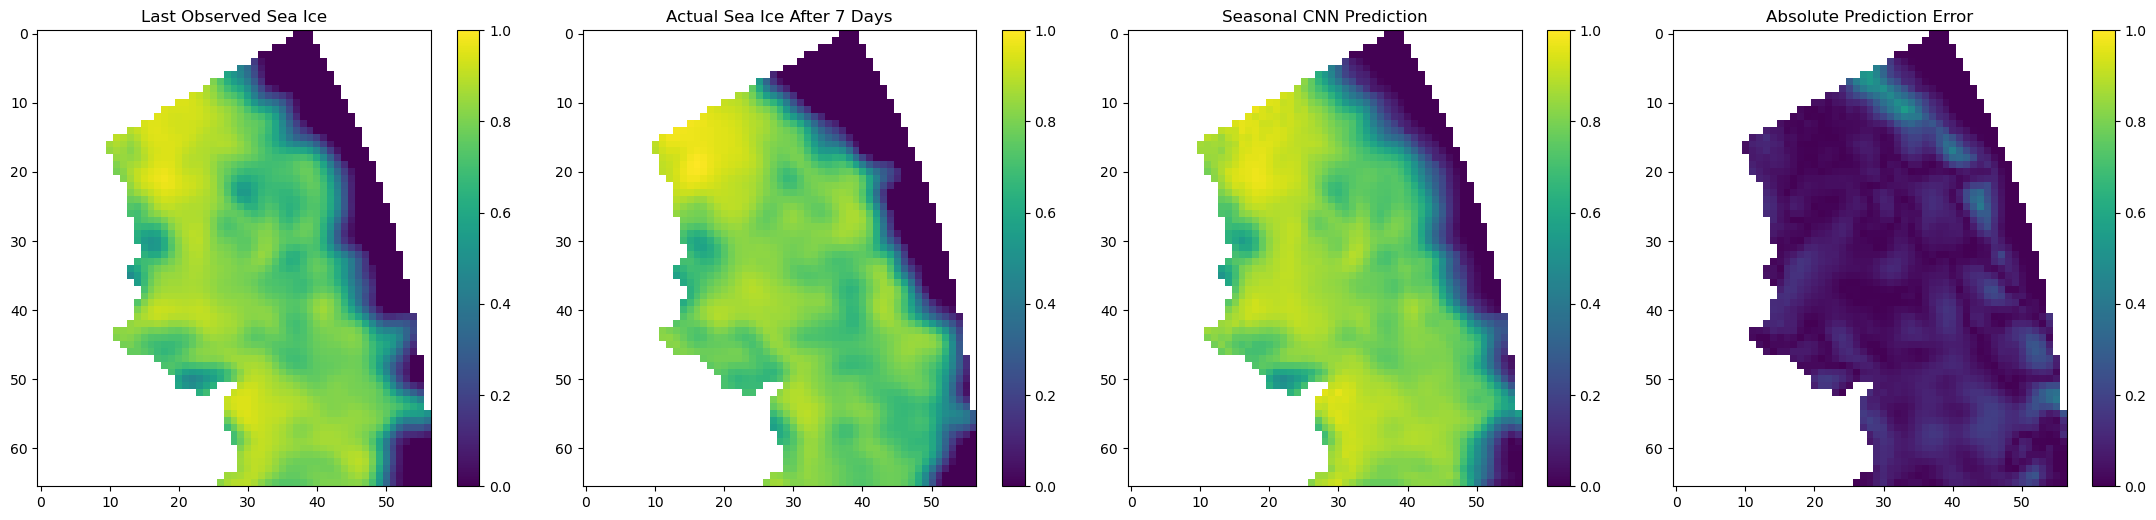

In [145]:
# First visualize one test prediction
# Select a test sample
sample_index = 0


# Get the last observed sea-ice map
last_observed = X_test_clean[sample_index, -1]


# Actual sea ice 7 days later
actual = y_test[sample_index]


# Seasonal CNN prediction
predicted = test_seasonal_cnn_pred[sample_index]


# Calculate absolute error
absolute_error = np.abs(actual - predicted)


# Apply spatial mask
last_observed_plot = np.where(
    spatial_mask,
    last_observed,
    np.nan
)

actual_plot = np.where(
    spatial_mask,
    actual,
    np.nan
)

predicted_plot = np.where(
    spatial_mask,
    predicted,
    np.nan
)

error_plot = np.where(
    spatial_mask,
    absolute_error,
    np.nan
)


# Create plots
fig, axes = plt.subplots(
    1,
    4,
    figsize=(22, 5)
)


# Last observed map
im1 = axes[0].imshow(
    last_observed_plot,
    vmin=0,
    vmax=1
)

axes[0].set_title(
    "Last Observed Sea Ice"
)

plt.colorbar(
    im1,
    ax=axes[0]
)


# Actual map
im2 = axes[1].imshow(
    actual_plot,
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Actual Sea Ice After 7 Days"
)

plt.colorbar(
    im2,
    ax=axes[1]
)


# Predicted map
im3 = axes[2].imshow(
    predicted_plot,
    vmin=0,
    vmax=1
)

axes[2].set_title(
    "Seasonal CNN Prediction"
)

plt.colorbar(
    im3,
    ax=axes[2]
)


# Error map
im4 = axes[3].imshow(
    error_plot,
    vmin=0,
    vmax=1
)

axes[3].set_title(
    "Absolute Prediction Error"
)

plt.colorbar(
    im4,
    ax=axes[3]
)


plt.tight_layout()

plt.show()

In [141]:
print("Sample index:", sample_index)

print("Test date stored:")
print(test_dates[sample_index])

Sample index: 0
Test date stored:
2025-07-01 00:00:00


## Save the model

In [155]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "seasonal_cnn.keras"

seasonal_cnn.save(model_path)

print("Model saved successfully!")
print("Location:", model_path.resolve())

Model saved successfully!
Location: D:\Jupyter\antarctic-navigation-ai\models\seasonal_cnn.keras


In [157]:
# Project-level artifacts folder
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

# Create folder if it doesn't exist
ARTIFACT_DIR.mkdir(exist_ok=True)

# Save spatial mask
mask_path = ARTIFACT_DIR / "spatial_mask.npy"

np.save(
    mask_path,
    spatial_mask.astype(bool)
)

print("Spatial mask saved successfully!")
print("Shape:", spatial_mask.shape)
print("Valid cells:", np.sum(spatial_mask))
print("Location:", mask_path.resolve())

Spatial mask saved successfully!
Shape: (66, 57)
Valid cells: 2108
Location: D:\Jupyter\antarctic-navigation-ai\artifacts\spatial_mask.npy


In [160]:

# Model configuration
model_config = {
    
    "model_name": "SeasonalResidualSeaIceCNN",
    
    "dataset": "NSIDC-0803 AMSR2 Southern Hemisphere Sea Ice Concentration",
    
    "region": {
        "name": "Bharati Station Region",
        "latitude_min": -70,
        "latitude_max": -60,
        "longitude_min": 60,
        "longitude_max": 90
    },
    
    "grid": {
        "height": 66,
        "width": 57,
        "valid_cells": int(np.sum(spatial_mask))
    },
    
    "forecast": {
        "input_days": 7,
        "forecast_horizon_days": 7
    },
    
    "input_features": {
        "total_channels": 9,
        "sea_ice_history_channels": 7,
        "seasonal_features": [
            "sin_day_of_year",
            "cos_day_of_year"
        ]
    },
    
    "target": {
        "variable": "sea_ice_concentration",
        "range": [0.0, 1.0]
    },
    
    "model_performance": {
        "validation": {
            "mae": 0.036965,
            "rmse": 0.082219
        },
        "test": {
            "mae": 0.075072,
            "rmse": 0.118857
        }
    }
}


# Save configuration
config_path = ARTIFACT_DIR / "model_config.json"

with open(config_path, "w") as file:
    json.dump(
        model_config,
        file,
        indent=4
    )


print("Model configuration saved successfully!")
print("Location:", config_path.resolve())

Model configuration saved successfully!
Location: D:\Jupyter\antarctic-navigation-ai\artifacts\model_config.json


In [163]:
np.save(
    ARTIFACT_DIR / "latitude_grid.npy",
    lat_aoi.astype(np.float32)
)

np.save(
    ARTIFACT_DIR / "longitude_grid.npy",
    lon_aoi.astype(np.float32)
)

print("Coordinate grids saved!")

print("Latitude:", (ARTIFACT_DIR / "latitude_grid.npy").resolve())
print("Longitude:", (ARTIFACT_DIR / "longitude_grid.npy").resolve())

Coordinate grids saved!
Latitude: D:\Jupyter\antarctic-navigation-ai\artifacts\latitude_grid.npy
Longitude: D:\Jupyter\antarctic-navigation-ai\artifacts\longitude_grid.npy


In [165]:
# Save latitude grid
np.save(
    ARTIFACT_DIR / "latitude_grid.npy",
    lat_aoi.astype(np.float32)
)

# Save longitude grid
np.save(
    ARTIFACT_DIR / "longitude_grid.npy",
    lon_aoi.astype(np.float32)
)

print("Coordinate grids saved successfully!")

print("\nLatitude file:")
print((ARTIFACT_DIR / "latitude_grid.npy").resolve())

print("\nLongitude file:")
print((ARTIFACT_DIR / "longitude_grid.npy").resolve())

Coordinate grids saved successfully!

Latitude file:
D:\Jupyter\antarctic-navigation-ai\artifacts\latitude_grid.npy

Longitude file:
D:\Jupyter\antarctic-navigation-ai\artifacts\longitude_grid.npy


In [166]:
saved_lat = np.load(
    ARTIFACT_DIR / "latitude_grid.npy"
)

saved_lon = np.load(
    ARTIFACT_DIR / "longitude_grid.npy"
)

print("Saved latitude shape:", saved_lat.shape)
print("Saved longitude shape:", saved_lon.shape)

print("\nLatitude range:")
print(
    np.nanmin(saved_lat),
    "to",
    np.nanmax(saved_lat)
)

print("\nLongitude range:")
print(
    np.nanmin(saved_lon),
    "to",
    np.nanmax(saved_lon)
)

Saved latitude shape: (66, 57)
Saved longitude shape: (66, 57)

Latitude range:
-72.47751 to -56.81248

Longitude range:
49.429558 to 89.78379
